# EDA – Porto taxi (samlet)

| Del | Innhold |
|---|---|
| 1–4 | Oversikt, NaN, kategoriske kolonner, MISSING_DATA, punkter per tur, turer per taxi |
| 5 | Typekonvertering, parsing av POLYLINE og avledede kolonner |
| 6 | Nye analyser: MISSING_DATA sammenlignet, TRIP_ID-duplikater, figurer |
| 7 | Felles rensing: endelige regler |
| 8 | Oppsummering og konsekvenser for skjema og innsetting |

## Oppsett

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("figures")       # lagre plott her, så de kan brukes i rapporten
FIG_DIR.mkdir(exist_ok=True)

# Hele filen er ~1,9 GB. Utvikle på et utvalg, kjør på alt til slutt.
NROWS = 1_000_000                 # sett til None for hele datasettet

---
# Del 1–4: Utforsking av rådata (hele datasettet)

In [2]:
# 1 og 2: Utforske og forstå datasettet

df = pd.read_csv("data/porto.csv")

df.head()


,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1372636858620000589,C,NaN,NaN,20000589,1372636858,A,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[..."
1,1372637303620000596,B,NaN,7.0,20000596,1372637303,A,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[..."
2,1372636951620000320,C,NaN,NaN,20000320,1372636951,A,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-..."
3,1372636854620000520,C,NaN,NaN,20000520,1372636854,A,False,"[[-8.574678,41.151951],[-8.574705,41.151942],[..."
4,1372637091620000337,C,NaN,NaN,20000337,1372637091,A,False,"[[-8.645994,41.18049],[-8.645949,41.180517],[-..."


In [3]:
print(df.head())
print("(Antall rader, antall kolonner)",df.shape)

               TRIP_ID CALL_TYPE  ORIGIN_CALL  ORIGIN_STAND   TAXI_ID  \
0  1372636858620000589         C          NaN           NaN  20000589   
1  1372637303620000596         B          NaN           7.0  20000596   
2  1372636951620000320         C          NaN           NaN  20000320   
3  1372636854620000520         C          NaN           NaN  20000520   
4  1372637091620000337         C          NaN           NaN  20000337   

    TIMESTAMP DAY_TYPE  MISSING_DATA  \
0  1372636858        A         False   
1  1372637303        A         False   
2  1372636951        A         False   
3  1372636854        A         False   
4  1372637091        A         False   

                                            POLYLINE  
0  [[-8.618643,41.141412],[-8.618499,41.141376],[...  
1  [[-8.639847,41.159826],[-8.640351,41.159871],[...  
2  [[-8.612964,41.140359],[-8.613378,41.14035],[-...  
3  [[-8.574678,41.151951],[-8.574705,41.151942],[...  
4  [[-8.645994,41.18049],[-8.645949,41.180517

In [4]:
print(df.columns)

Index(['TRIP_ID', 'CALL_TYPE', 'ORIGIN_CALL', 'ORIGIN_STAND', 'TAXI_ID',
       'TIMESTAMP', 'DAY_TYPE', 'MISSING_DATA', 'POLYLINE'],
      dtype='str')


In [5]:
# 3. Utforske Nan verdier

df.isna().sum()

TRIP_ID               0
CALL_TYPE             0
ORIGIN_CALL     1345900
ORIGIN_STAND     904091
TAXI_ID               0
TIMESTAMP             0
DAY_TYPE              0
MISSING_DATA          0
POLYLINE              0
dtype: int64

In [6]:
pd.crosstab(
    df["CALL_TYPE"],
    df["ORIGIN_CALL"].isna(),
    rownames=["CALL_TYPE"],
    colnames=["ORIGIN_CALL missing"]
)


ORIGIN_CALL missing,False,True
CALL_TYPE,,
A,364770,0
B,0,817881
C,0,528019


In [7]:
pd.crosstab(
    df["CALL_TYPE"],
    df["ORIGIN_STAND"].isna(),
    rownames=["CALL_TYPE"],
    colnames=["ORIGIN_STAND missing"]
)

ORIGIN_STAND missing,False,True
CALL_TYPE,,
A,0,364770
B,806579,11302
C,0,528019


In [8]:
df["CALL_TYPE"].value_counts()

CALL_TYPE
B    817881
C    528019
A    364770
Name: count, dtype: int64

Gjennom analysen av NaN verdier hittil ser vi at det er en god del NaN verdier som mangler i ORIGIN_CALL og ORIGIN_STAND. Her kan man fort tenke at det er smart å kvitte seg med disse verdiene eller gjøre noe form for dataimputering, men før en beslutning må vi forstå hva kolonnene og potensielle Null verdier representerer.

Ifølge oppgaven er ORIGIN_CALL IDen til kunden som initierte samtalen, og har kun en verdi når CALL_TYPE = A, ellers null. ORIGIN_STAND er IDen til taxistanden hvor turen startet, og har en verdi kun hvis CALL_TYPE = B. Dette forteller oss at vi må se på relasjonen mellom CALL_TYPE og ORIGIN_STAND/CALL:

Vi lagde derfor to crosstabs som forteller oss hvor og når NaN verdier oppstår. Ifølge crosstaben ser vi at når CALL_TYPE = A så finnes det ingen NaN verdier i ORIGIN_CALL, men når den er B eller C er alle NaN. Dette henger med beskrivelsen av selve kolonnen. For ORIGIN_STAND er det fortsatt 11302 NaN verdier når CALL_TYPE = B. Disse verdiene er faktiske mangler i datasettet. Vi velger å beholde alle NaN verdier, også de som viser til faktiske mangler. Dette er fordi ORIGIN_STAND ikke er veldig sentralt i senere analyser, og ved å slette 11000 rader kan vi miste annen verdifull informasjon. Imputering er heller ikke relevant med tanke på at det ikke finnes en pålitelig måte å legge til ID-verdier.

In [9]:
print("Rows with missing GPS points:", df["MISSING_DATA"].sum())

Rows with missing GPS points: 10


MISSING_DATA forteller oss om det finnes turer som mangler GPS punkter, og vi ser at det finnes 10 turer med gps mangler. I senere analyser er POLYLINE sentralt fordi vi skal blant annet finne ut varighet, tid, distanse og lignende. Hvis vi mangler GPS-punkter, vet vi ikke om de manglende punktene ligger i starten, midten eller slutten av turen. Dermed kan vi heller ikke være sikre på at det faktisk er 15 sekunder mellom alle registrerte punkter i disse 10 radene. Imputering av gps punkter her vil heller ikke gå fordi vi ikke vet hvor manglene ligger. Vi velger derfor å slette disse 10 radene grunnet at dette vil øke påliteligheten til POLYLINE kolonnen, og det er så få rader at vi ikke mister masse verdifull data.

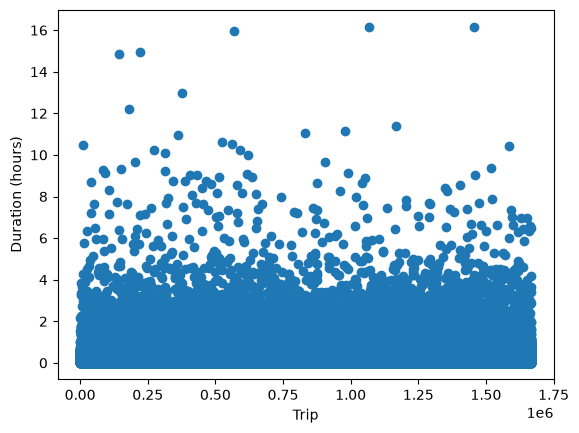

count    1666766.00
mean           0.20
std            0.19
min            0.01
25%            0.12
50%            0.17
75%            0.24
max           16.17
dtype: float64

In [20]:
# 4. Utforsking av datakarakteristikker

durations = []

for polyline in df["POLYLINE"]:
    points = json.loads(polyline)
    if len(points) >= 3:
        duration = (len(points) - 1) * 15 / 3600
        durations.append(duration)

plt.scatter(range(len(durations)), durations)
plt.xlabel("Trip")
plt.ylabel("Duration (hours)")
plt.show()


pd.Series(durations).describe().round(2)

In [16]:
point_counts = []

for polyline in df["POLYLINE"]:
    points = json.loads(polyline)
    point_counts.append(len(points))

point_series = pd.Series(point_counts)
print(point_series.describe())



count    1.710670e+06
mean     4.875831e+01
std      4.565372e+01
min      0.000000e+00
25%      2.800000e+01
50%      4.100000e+01
75%      5.900000e+01
max      3.881000e+03
dtype: float64


POLYLINE inneholder GPS punktene for hver tur, og er derfor viktig for flere av analysene senere. Vi undersøkte hvor mange GPS punkter hver tur har. En vanlig tur har rundt 41 GPS punkter i median, mens gjennomsnittet ligger på omtrent 49 punkter.  
Varigheten ble beregnet ut fra at det er 15 sekunder mellom hvert GPS punkt. For å få en mer pålitelig varighetsanalyse tok vi kun med turer med minst 3 GPS punkter. Medianen på varigheten er omtrent 0.17 timer, altså rundt 10 minutter, mens gjennomsnittet er omtrent 0.20 timer eller 12 minutter. De fleste turene er derfor relativt korte, men vi ser også noen tydelige outliers. Den lengste turen er på omtrent 16.17 timer, som skiller seg mye fra resten av datasettet. Vi velger likevel ikke å fjerne disse kun fordi de er outliers, siden vi ikke vet om de faktisk er feilregistreringer.

DAY_TYPE
A    1.0
Name: proportion, dtype: float64


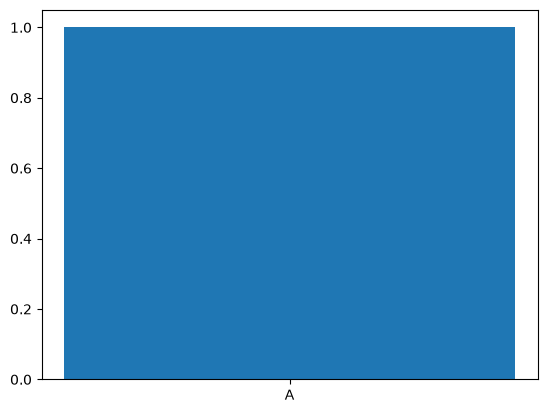

In [13]:
plt.bar(df["DAY_TYPE"].value_counts().index, df["DAY_TYPE"].value_counts(normalize=True))

print(df["DAY_TYPE"].value_counts(normalize=True))

Plottet DAY_TYPE for å se fordelingen mellom de ulike klassene, og vi ser at den alltid er A som vil si at det ikke er noe variasjon og behov for videre analyse.

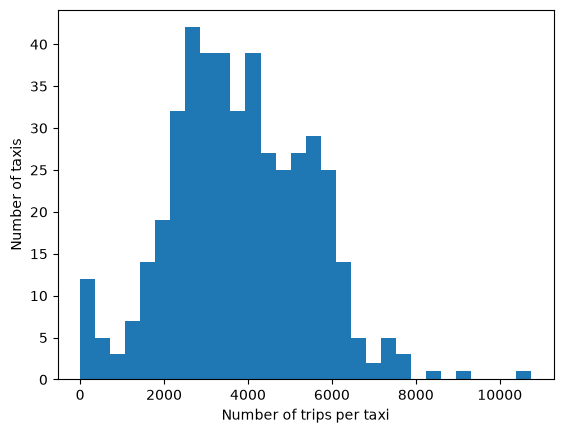

In [22]:
tur_per_taxi = df["TAXI_ID"].value_counts()

plt.hist(tur_per_taxi, bins=30)
plt.xlabel("Number of trips per taxi")
plt.ylabel("Number of taxis")
plt.show()

Fordelingen av antall turer per taxi viser at de fleste taxiene har mellom omtrent 2000 og 6000 turer. Det finnes også noen taxier med veldig få turer, og noen få med betydelig flere turer enn resten. Den høyeste ligger på over 10 000 turer, som skiller seg tydelig ut fra hoveddelen av datasettet.

---
# Del 5–8

Del 5 leser inn på nytt med `NROWS` (utvalg under utvikling, sett `NROWS = None` for alt). Dette erstatter `df` fra del 1–4.

In [109]:
# TODO: les inn porto.csv (bruk NROWS). Vurder dtype= og usecols= for å spare minne.
# Les: https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

df = pd.read_csv("data/porto.csv", nrows=NROWS)

---
# 5. Datatransformasjon

Artikkelen nevner: **skalering** (min-max, standardisering), **encoding** av kategorier (one-hot, label),
**matematiske transformasjoner** (f.eks. log), **avledede features** og **aggregering**.

For oss er de to siste viktigst: de fleste spørsmålene i Part 2 handler om størrelser som ikke finnes som kolonner
(varighet, distanse, sluttid, start/slutt-punkt). Det dere finner ut her, avgjør også hva som bør forhåndsberegnes i databasen.

## 5.1 Typekonvertering

- `TIMESTAMP` er Unix-sekunder. Konverter til datetime. **Hvilken tidssone?** Datasettkilden sier hva tidsstemplet betyr. Velg og skriv ned.
- `CALL_TYPE` og `DAY_TYPE` har få unike verdier. Hva sparer dere på `category`-dtype? (`df.memory_usage(deep=True)` før/etter)
- `MISSING_DATA`: er den faktisk bool, eller tekst `"True"`/`"False"`?
- `ORIGIN_CALL` / `ORIGIN_STAND` er float pga. NaN. Hva bør typen være i MySQL?

In [110]:
# TODO: TIMESTAMP -> datetime (pd.to_datetime, unit="s", eventuelt tz_localize/tz_convert)
df["utc_start_time"] = pd.to_datetime(df.TIMESTAMP, unit="s", utc=True)
#kategoriske kolonner -> "category", sammenlign minnebruk før/etter
minne_for = df.memory_usage(deep=True)
print(minne_for/1024**2)

df["DAY_TYPE"] = df.DAY_TYPE.astype("category")
df["CALL_TYPE"] = df.CALL_TYPE.astype("category")
df.dtypes
minne_etter = df.memory_usage(deep=True)
print (minne_etter/1024**2)

Index                0.000126
TRIP_ID              7.629395
CALL_TYPE           47.683716
ORIGIN_CALL          7.629395
ORIGIN_STAND         7.629395
TAXI_ID              7.629395
TIMESTAMP            7.629395
DAY_TYPE            47.683716
MISSING_DATA         0.953674
POLYLINE          1059.806938
utc_start_time       7.629395
dtype: float64
Index                0.000126
TRIP_ID              7.629395
CALL_TYPE            0.953817
ORIGIN_CALL          7.629395
ORIGIN_STAND         7.629395
TAXI_ID              7.629395
TIMESTAMP            7.629395
DAY_TYPE             0.953722
MISSING_DATA         0.953674
POLYLINE          1059.806938
utc_start_time       7.629395
dtype: float64


**Tolkning:** _Hva viser resultatet over? Hva betyr det for rensing, skjema eller spørringer?_

## 5.2 Parse POLYLINE

POLYLINE er en JSON-streng. Den må bli en liste av `[lon, lat]`-par før dere kan regne på den.

- Merk rekkefølgen: **lengdegrad først**, så breddegrad.
- Hvor lang tid tar parsingen på utvalget? Hva betyr det for hele datasettet og for innsettingsskriptet?

In [111]:
# TODO: parse POLYLINE med json.loads (Series.apply). Mål tiden med %%time eller time.perf_counter.
df["POLYLINE"] = df.POLYLINE.apply(json.loads)
df.dtypes

TRIP_ID                        int64
CALL_TYPE                   category
ORIGIN_CALL                  float64
ORIGIN_STAND                 float64
TAXI_ID                        int64
TIMESTAMP                      int64
DAY_TYPE                    category
MISSING_DATA                    bool
POLYLINE                      object
utc_start_time    datetime64[s, UTC]
dtype: object

## 5.3 Avledede features

Lag én kolonne om gangen og sjekk resultatet (`describe()`, noen eksempelrader) før dere går videre.

| Feature | Hint | Brukes i |
|---|---|---|
| `n_points` | lengden av lista | Part 2 oppg. 1, 7 |
| `duration_s` | punktene er tatt hvert **15. sekund**. Er varigheten `n·15` eller `(n−1)·15`? Sjekk definisjonen i datasettkilden. | 4b, 5, 8, 10 |
| `start_time`, `end_time` | `TIMESTAMP` + varighet (`pd.to_timedelta`) | 8, 10 |
| `start_lon/lat`, `end_lon/lat` | første og siste element. Hva skjer med tomme lister? | 9 |
| `hour`, `weekday`, `month` | `.dt`-accessoren | 4b, steg 6 |
| `crosses_midnight` | sammenlign *dato* for start og slutt | 8 |
| `distance_km` | sum av haversine mellom påfølgende punkter (`haversine`-pakken står i `requirements.txt`) | 4b, 5 |
| `avg_speed_kmh` | distanse / varighet. Hva med varighet 0? | steg 7 |

Distanse er den dyreste. Skriv en funksjon som tar én polyline og returnerer km, test den på 2–3 turer for hånd, og kjør den deretter på utvalget.

In [138]:
#n_points og duration_s
df["N_POINTS"] = df.POLYLINE.apply(len)
df["DURATION_S"] = (df.N_POINTS-1)*15
df["DURATION_S"] = df["DURATION_S"].clip(lower=0)
df["DURATION_S"].describe()

count    1000000.000000
mean         716.055660
std          688.287167
min            0.000000
25%          405.000000
50%          600.000000
75%          870.000000
max        57525.000000
Name: DURATION_S, dtype: float64

In [140]:
#start_time, end_time, hour, weekday, month, crosses_midnight
df["end_time"] = df["utc_start_time"] + pd.to_timedelta(df["DURATION_S"], unit="s")

df["hour"] = df["utc_start_time"].dt.hour

#0=monday
df["weekday"] = df["utc_start_time"].dt.weekday

df["month"] = df["utc_start_time"].dt.month

df["crosses_midnight"] = df["utc_start_time"].dt.date != df["end_time"].dt.date


In [143]:
# start/slutt-koordinater (håndter tomme polylines)
df["start_lon"] = df.POLYLINE.apply(lambda p: p[0][0] if p else np.nan)
df["start_lat"] = df.POLYLINE.apply(lambda p: p[0][1] if p else np.nan)
df["end_lon"] = df.POLYLINE.apply(lambda p: p[-1][0] if p else np.nan)
df["end_lat"] = df.POLYLINE.apply(lambda p: p[-1][1] if p else np.nan)
df["start_lon, start_lat, end_lon, end_lat"].describe()

count    996741.000000
mean         -8.616910
std           0.030454
min         -17.719776
25%          -8.628750
50%          -8.612640
75%          -8.603487
max          -0.205893
Name: start_lon, dtype: float64

In [147]:
#funksjon polyline_distance_km(polyline) -> float
from haversine import haversine

def polyline_distance_km(polyline) -> float:
    distance: float = 0.0
    
    for i, j in zip(polyline, polyline[1:]):
        distance += haversine((i[1], i[0]), (j[1], j[0]))
    return distance
    
df["distance_km"] = df.POLYLINE.apply(polyline_distance_km)
df["distance_km"].describe()


count    1000000.000000
mean           5.499369
std            7.823110
min            0.000000
25%            2.368002
50%            3.920650
75%            6.468928
max         1207.349172
Name: distance_km, dtype: float64

In [148]:
# TODO: avg_speed_kmh
df["avg_speed_kmh"] = (df.distance_km/df.DURATION_S.replace(0, np.nan))*3600
df.avg_speed_kmh.describe()

count    979866.000000
mean         27.543107
std          41.446510
min           0.000000
25%          18.018963
50%          23.963660
75%          32.834312
max       28835.193605
Name: avg_speed_kmh, dtype: float64

**Tolkning:** _Hva viser resultatet over? Hva betyr det for rensing, skjema eller spørringer?_

---
# 6. Krevde EDA-punkter

## 6.1 MISSING_DATA – forekomst og konsekvens

Oppgaven nevner dette eksplisitt («investigate the presence and impact of missing trajectories»).
- Hvilke verdier har kolonnen, og hvor mange turer har `True`? (antall og andel)
- Ser disse turene annerledes ut enn resten? Sammenlign f.eks. `N_POINTS`, `DURATION_S`, `distance_km`
  for `True` mot `False` (hint: `groupby("MISSING_DATA")[...]`).
- Konsekvens: beholde, flagge eller fjerne? Hva betyr valget for varighet/distanse i Part 2?

*Antall (10 av 1 710 670) er talt i del 3 over. Her: sammenligning med resten.*

In [169]:
df2 = pd.read_csv('data/porto.csv', usecols=["TRIP_ID", "MISSING_DATA"])
df2.head()

,TRIP_ID,MISSING_DATA
0,1372636858620000589,False
1,1372637303620000596,False
2,1372636951620000320,False
3,1372636854620000520,False
4,1372637091620000337,False


In [ ]:
# TODO: sammenlign turer med og uten MISSING_DATA


**Tolkning:** _Hva viser resultatet over? Hva betyr det for rensing, skjema eller spørringer?_

## 6.2 TRIP_ID – unik?
TRIP_ID skal bli primærnøkkel. Finnes det duplikater? Er duplikatene identiske rader eller ulike turer?
Hint: `duplicated()`, `nunique()`.

In [171]:
# TODO: sjekk duplikater i TRIP_ID
print(len(df2["TRIP_ID"]) - df2["TRIP_ID"].nunique())

81


**Tolkning:** _Hva viser resultatet over? Hva betyr det for rensing, skjema eller spørringer?_
Resultatet over viser at om man tar antall rader som finnes totalt i csv filen og trekker fra alle unike verdier i "TRIP_ID" kolonnen så får man 81. Dette vil si at det er 81 verdier i kolonnen som er duplikate. Hvis man skal bruke "TRIP_ID" som PK, så må man fjerne alle duplikate entries.

## 6.3 Fordeling av hovedattributter
`CALL_TYPE` og `DAY_TYPE` (stolpediagram med antall/andel), og fordelingen av `N_POINTS` eller `DURATION_S` (histogram, gjerne log-akse).
Lagre 2–3 figurer til rapporten: `fig.savefig(FIG_DIR / "navn.png", dpi=150, bbox_inches="tight")`. Tittel og aksenavn med enhet.

<Axes: xlabel='DAY_TYPE'>

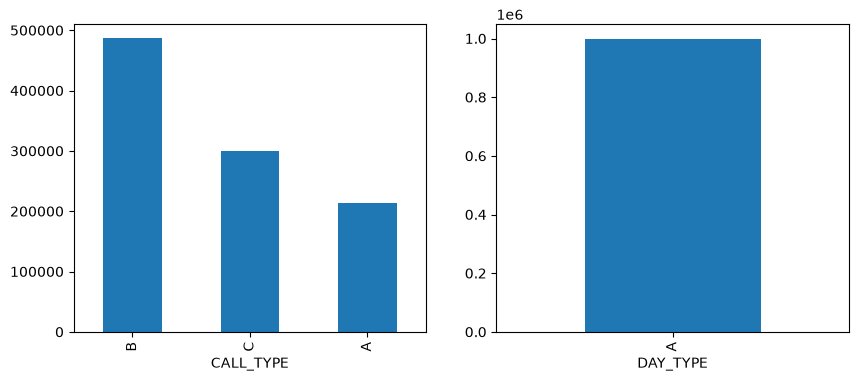

In [194]:
# TODO: stolpediagram CALL_TYPE og DAY_TYPE
fig, (ax, bx) = plt.subplots(1,2, figsize=(10,4))
df["CALL_TYPE"].value_counts().plot.bar(ax=ax)
df["DAY_TYPE"].value_counts().plot.bar(ax=bx)


(array([8.79540e+05, 1.03681e+05, 1.03120e+04, 2.98000e+03, 1.31400e+03,
        7.50000e+02, 4.31000e+02, 2.79000e+02, 1.72000e+02, 1.27000e+02,
        9.70000e+01, 5.60000e+01, 4.60000e+01, 3.70000e+01, 3.40000e+01,
        2.10000e+01, 1.60000e+01, 9.00000e+00, 1.20000e+01, 1.20000e+01,
        5.00000e+00, 5.00000e+00, 9.00000e+00, 1.10000e+01, 5.00000e+00,
        5.00000e+00, 4.00000e+00, 7.00000e+00, 6.00000e+00, 1.00000e+00,
        2.00000e+00, 2.00000e+00, 4.00000e+00, 1.00000e+00, 2.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00,
        1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 2.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([   0.  ,   76.72,  153.44,  230.16,  306.88,  383.6 ,  460.32,
         537.04,  613.76,  690.48,  767.2 ,  843.92,  920.64,  997.36,
        1074.08, 1150.8 , 1227.52, 1304.24, 1380.96, 1457.68, 1534.4 ,
        1611.12, 1687.84, 1764.56, 1841.28, 1918.  , 19

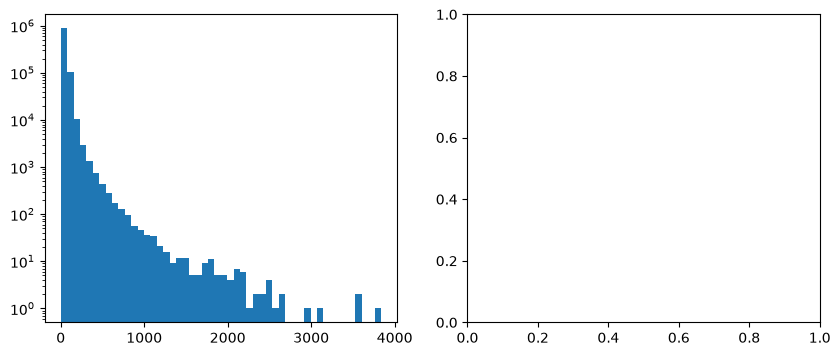

In [198]:
# TODO: histogram N_POINTS eller DURATION_S
fig, (cx, dx) = plt.subplots(1,2, figsize=(10,4))
cx.set_yscale("log")
cx.hist(df["N_POINTS"].dropna(), bins=50)

**Tolkning:** _Hva viser resultatet over? Hva betyr det for rensing, skjema eller spørringer?_

---
# 7. Ugyldige turer og outliers (kort)

Skill mellom **feil i data**, **ugyldige turer etter oppgavens definisjon** (< 3 punkter, Part 2 oppg. 7) og **sjeldne, men gyldige** turer.
- Tell turer med 0, 1 og 2 punkter.
- Se på ekstreme verdier i `DURATION_S`, `distance_km` og `avg_speed_kmh` (`describe()`, høyeste verdier). Er de fysisk mulige?

In [ ]:
# TODO: tell turer med < 3 punkter og se på ekstreme verdier


**Tolkning:** _Hva viser resultatet over? Hva betyr det for rensing, skjema eller spørringer?_

## 7.1 Beslutning per type

| Type | Regel / terskel | Antall (andel) | Tiltak | Begrunnelse |
|---|---|---|---|---|
| < 3 punkter | | | | |
| Ekstrem varighet / hastighet | | | | |
| `MISSING_DATA = True` | | | | |
| Duplikat `TRIP_ID` | | | | |

Husk: Part 2 oppg. 7 spør om antall turer med < 3 punkter. Fjerner dere dem, hvordan svarer dere da på oppgaven?

---
# 8. Funn og konsekvenser (utkast til rapporten)
Skriv med egne ord, kort, og henvis til figurene i `figures/`.

## 8.1 Nøkkelfunn
_3–5 punkter: funn + tall + figur. Oppgi om tallene er fra utvalget eller hele datasettet._

- _…_

## 8.2 Konsekvenser for skjema og innsetting
- _Hvilke avledede verdier fra 5.3 lagres i databasen?_
- _Hvordan lagres POLYLINE (egen punkttabell, JSON, begge)?_
- _Datatyper, NULL-verdier og tidssone._
- _Renseregler fra 7.1._